# Snx17 comparison: two independent equilibration and assays

Keep this notebook and `ode_parameters.yaml` together. Start Jupyter in that folder; install PyYAML with `%pip install pyyaml` if needed. **Restart Kernel and Run All** after changing parameters.

Each assay starts from its own complete equilibrated state and adds the configured assay proteins.

**AUC definition:** **A**rea **U**nder the **C**urve. Trapezoidal integration over the same configured assay interval, excluding equilibration. The primary curve is the original normalised probe-signal loss, `1 - PbA(t)/max(PbA)` (maximum calculated separately within each assay). AUC units are seconds. **AUCR = AUC at 300 nM / AUC at 0 nM**. Values above 1 mean greater integrated probe-signal loss, not greater remaining probe. Raw PI(3)P, raw bound probe, and normalised PI(3)P depletion are also compared


## 1. Imports

In [1]:
import sys
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
import csv

# S = Snx17
# M = MTM1
# P = ProbeN
# A = Pi3P
# B = Pi
# C = Cargo

## 2. Load YAML parameters

In [2]:
from pathlib import Path
import yaml

# Keep the YAML beside this notebook and start Jupyter in that folder.
CONFIG_PATH = Path("ode_parameters.yaml").resolve()
with CONFIG_PATH.open(encoding="utf-8") as f:
    config = yaml.safe_load(f)

affinities = config["affinities"]
Volume = config["geometry"]["Volume"]
TotalMembraneSA = config["geometry"]["TotalMembraneSA"]

keff_M = config["catalysis"]["keff_M"]
keff_SM = config["catalysis"]["keff_SM"]
if keff_SM is None:
    keff_SM = keff_M

params = dict(config["association_rates"])
ref = config["dissociation_reference"]
for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                        ("PA", "Kd_PA"), ("PB", "Kd_PB")]:
    reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
    params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])
for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC")]:
    params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])

divisors = config["complex_off_rate_divisors"]
params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
params.update(keff_M=keff_M, keff_SM=keff_SM,
              ka=config["transport"]["ka"])

eq_Snx17_conc = config["equilibration"]["Snx17_conc"]
eq_MTM1_conc = config["equilibration"]["MTM1_conc"]
eq_Probe_conc = config["equilibration"]["Probe_conc"]
eq_cargo_conc = config["equilibration"]["cargo_fraction"]
PC_concentration = config["membrane"]["PC_concentration"]
membrane_substrate = config["membrane"]["membrane_substrate"]
membrane_product = config["membrane"]["membrane_product"]
equilibration_time = config["equilibration"]["time_s"]
initial_Snx17_conc = config["assay"]["Snx17_conc"]
initial_MTM1_conc = config["assay"]["MTM1_conc"]
initial_Probe_conc = config["assay"]["Probe_conc"]
simulation_time = config["assay"]["time_s"]
solver_options = dict(config["solver"])
file_settings = config["files"]
experimental_csv = CONFIG_PATH.parent / file_settings["experimental_csv"]
results_csv = CONFIG_PATH.parent / file_settings["results_csv"]


## 3. Initial-state template and ODE model


In [3]:
equilibration_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    eq_Snx17_conc, # Sf
    eq_MTM1_conc, # Mf
    eq_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    PC_concentration * membrane_substrate, # A
    PC_concentration * membrane_product, # B
    PC_concentration * eq_cargo_conc # C
]

# ===================== ODE Model =====================

def change_in_bidning(kon, substrate,
                      koff, free_form, bound_form):
    return kon * substrate * free_form - koff * bound_form


def model(t, y, parameter_values=None, volume_um3=None, area_um2=None):
    # Optional input lets the sensitivity runs use their own settings.
    p = params if parameter_values is None else parameter_values
    volume = Volume if volume_um3 is None else volume_um3
    area = TotalMembraneSA if area_um2 is None else area_um2
    Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, A, B, C = y

    kon_SA   = p["kon_SA"]
    koff_SA  = p["koff_SA"]
    kon_MA   = p["kon_MA"]
    koff_MA  = p["koff_MA"]
    kon_PA   = p["kon_PA"]
    koff_PA  = p["koff_PA"]
    kon_PB   = p["kon_PB"]
    koff_PB  = p["koff_PB"]
    kon_SM   = p["kon_SM"]
    koff_SM  = p["koff_SM"]
    koff_SAM = p["koff_SAM"]
    kon_SC   = p["kon_SC"]
    koff_SC  = p["koff_SC"]
    koff_SAC = p["koff_SAC"]
    keff_M   = p["keff_M"]
    keff_SM  = p["keff_SM"]
    ka       = p["ka"]

    # =================================== ODE equations
    # Free lipid/cargo available for binding
    A_bind = max((A - SbA - MbA - PbA - (SMb * 2) - SbC), 0.0)
    B_bind = max((B - PbB), 0.0)
    C_bind = max((C - SbC), 0.0)

    # Convert nM to molecules/um2 for 2D binding calculations
    aMbA = ((MbA * 0.602) * volume) / area
    aSbA = ((SbA * 0.602) * volume) / area
    aSMb = ((SMb * 0.602) * volume) / area
    aC_bind = ((C_bind * 0.602) * volume) / area
    aSbC = ((SbC * 0.602) * volume) / area

    # 2D reaction rates (molecules/um2/s)
    # S·A + M·A <-> SM (both membrane-bound)
    SMb_rate_mum2 = change_in_bidning(kon_SM, aMbA, koff_SM, aSbA, aSMb)

    # S·A + C <-> S·A·C (S must already be membrane-bound via A)
    SbC_rate_mum2 = change_in_bidning(kon_SC, aC_bind, koff_SC, aSbA, aSbC)

    # Convert 2D rates back to nM/s
    SMb_rate_nM = (SMb_rate_mum2 * area) / (0.602 * volume)
    SbC_rate_nM = (SbC_rate_mum2 * area) / (0.602 * volume)

    # Diffusion from compartment 1 -> compartment 2
    dSa = -(ka * Sa)
    dMa = -(ka * Ma)
    dPa = -(ka * Pa)

    # Calculating state changes in compartment 2
    # Free S, M, and P
    dSf = -change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          (koff_SAC * SbC) + \
          (koff_SAM * SMb) + (ka * Sa)

    dMf = -change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          (koff_SAM * SMb) + (ka * Ma)

    dPf = -change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA) + \
          -change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB) + (ka * Pa)

    # Binding from compartment 2 -> compartment 3
    dSbA = change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          -SMb_rate_nM + \
          -SbC_rate_nM

    dMbA = change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          -SMb_rate_nM

    dPbA = change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA)
    dPbB = change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB)

    # SAM complex
    dSMb = SMb_rate_nM - (koff_SAM * SMb)

    # SAC complex
    dSbC = SbC_rate_nM - (koff_SAC * SbC)

    # Catalysis: PI(3)P -> PI
    dB = (keff_M * MbA * A_bind) + (keff_SM * SMb * A_bind)
    dA = -dB

    return [dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB,
            dSMb, dSbC, dA, dB, 0]


## 4. Common settings

In [4]:
label_list = ["[undelivered Snx17]", "[undelivered MTM1]", "[undelivered Pi3P Probe]", "[solution Snx17]", "[solution MTM1]", "[solution Pi3P Probe]",
              "[Pi3P-bound Snx17]", "[Pi3P-bound MTM1]", "[Pi3P-bound Pi3P Probe]", "[Pi-bound Pi3P Probe]", "[Pi3P-bound Snx17-MTM1]",
              "[Pi3P-bound Snx17-Cargo]", "[Pi3P]", "[Pi]", "[Cargo]"]
colour_list = ["grey", "grey", "grey", "cyan", "green", "olive", "blue", "gold",
              "orange", "purple", "fuchsia", "tan", "red", "plum", "thistle"]

# The same assay interval and rate settings are used for both scenarios.
def current_setup():
    import json
    return json.dumps({"params": params, "Volume": Volume,
                       "TotalMembraneSA": TotalMembraneSA,
                       "initial_template": equilibration_concentrations,
                       "equilibration_time": equilibration_time,
                       "simulation_time": simulation_time,
                       "solver": solver_options,
                       "assay_additions": [initial_Snx17_conc, initial_MTM1_conc,
                                           initial_Probe_conc]}, sort_keys=True)

if simulation_time[1] <= simulation_time[0]:
    raise ValueError("Assay end time must be greater than its start time.")


## 5. Equilibration — 0 nM Snx17

In [5]:
eq_initial_0 = np.array(equilibration_concentrations, dtype=float).copy()
eq_initial_0[3] = 0.0  # free Snx17 (nM); override YAML for this scenario
setup_0 = current_setup()
sol_eq_0 = solve_ivp(model, equilibration_time, eq_initial_0, **solver_options)
if not sol_eq_0.success:
    raise RuntimeError(sol_eq_0.message)
y_eq_0 = sol_eq_0.y[:, -1].copy()
print("0 nM Snx17: equilibration complete.")

0 nM Snx17: equilibration complete.


## 6. Assay — from 0 nM Snx17 equilibration

In [6]:
if current_setup() != setup_0:
    raise RuntimeError("Parameters changed. Re-run this scenario's equilibration first.")
# Preserve every equilibrated species, then add assay proteins once.
assay_initial_0 = y_eq_0.copy()
assay_initial_0[3] += initial_Snx17_conc
assay_initial_0[4] += initial_MTM1_conc
assay_initial_0[5] += initial_Probe_conc
sol_assay_0 = solve_ivp(model, simulation_time, assay_initial_0, **solver_options)
if not sol_assay_0.success:
    raise RuntimeError(sol_assay_0.message)
assay_setup_0 = setup_0
print("0 nM Snx17: assay complete.")

0 nM Snx17: assay complete.


## 7. Equilibration — 300 nM Snx17

In [7]:
eq_initial_300 = np.array(equilibration_concentrations, dtype=float).copy()
eq_initial_300[3] = 300.0  # free Snx17 (nM); override YAML for this scenario
setup_300 = current_setup()
sol_eq_300 = solve_ivp(model, equilibration_time, eq_initial_300, **solver_options)
if not sol_eq_300.success:
    raise RuntimeError(sol_eq_300.message)
y_eq_300 = sol_eq_300.y[:, -1].copy()
print("300 nM Snx17: equilibration complete.")

300 nM Snx17: equilibration complete.


## 8. Assay — from 300 nM Snx17 equilibration

In [8]:
if current_setup() != setup_300:
    raise RuntimeError("Parameters changed. Re-run this scenario's equilibration first.")
# Preserve every equilibrated species, then add assay proteins once.
assay_initial_300 = y_eq_300.copy()
assay_initial_300[3] += initial_Snx17_conc
assay_initial_300[4] += initial_MTM1_conc
assay_initial_300[5] += initial_Probe_conc
sol_assay_300 = solve_ivp(model, simulation_time, assay_initial_300, **solver_options)
if not sol_assay_300.success:
    raise RuntimeError(sol_assay_300.message)
assay_setup_300 = setup_300
print("300 nM Snx17: assay complete.")

300 nM Snx17: assay complete.


## 9. Calculate AUCs and AUCRs

In [9]:
if not (assay_setup_0 == assay_setup_300 == current_setup()):
    raise RuntimeError("Settings differ between runs. Restart Kernel and Run All.")

def calculate_auc(t, values):
    t, values = np.asarray(t), np.asarray(values)
    if len(t) < 2 or np.any(np.diff(t) <= 0):
        raise ValueError("AUC requires at least two strictly increasing times.")
    if not np.all(np.isfinite(values)):
        return np.nan
    return float(np.sum(np.diff(t) * (values[:-1] + values[1:]) / 2))

def normalised_loss(values):
    peak = np.max(values)
    if peak <= 0:
        return np.full_like(values, np.nan)  # undefined if no starting signal
    return 1 - values / peak

runs = {0: sol_assay_0, 300: sol_assay_300}
curves = {}
for dose, result in runs.items():
    if not np.allclose(result.t[[0, -1]], simulation_time, rtol=0, atol=1e-9):
        raise ValueError("Both assays must cover the entire configured interval.")
    curves[dose] = {
        "Normalised probe-signal loss": normalised_loss(result.y[8]),
        "Normalised PI(3)P depletion": normalised_loss(result.y[12]),
        "Bound PI(3)P probe": result.y[8].copy(),
        "Total PI(3)P": result.y[12].copy(),
    }

rows = []
for metric in curves[0]:
    auc_0 = calculate_auc(sol_assay_0.t, curves[0][metric])
    auc_300 = calculate_auc(sol_assay_300.t, curves[300][metric])
    ratio = auc_300 / auc_0 if np.isfinite(auc_0) and abs(auc_0) > 1e-12 else np.nan
    rows.append({"Curve": metric,
                 "AUC units": "s" if metric.startswith("Normalised") else "nM s",
                 "AUC (0 nM Snx17)": auc_0,
                 "AUC (300 nM Snx17)": auc_300,
                 "AUCR (300 / 0)": ratio})
auc_summary = pd.DataFrame(rows)
primary_metric = "Normalised probe-signal loss"  # choose any curve name above
primary_result = auc_summary.loc[auc_summary["Curve"] == primary_metric].iloc[0]
AUCR = primary_result["AUCR (300 / 0)"]
print(f"Assay integration interval: {simulation_time[0]}–{simulation_time[1]} s")
print(auc_summary.to_string(index=False, float_format=lambda x: f"{x:.6g}"))
print(f"\nPrimary AUCR ({primary_metric}, 300 / 0): {AUCR:.6g}")
print("NaN means the signal or reference AUC was undefined/zero.")

Assay integration interval: 0–1200 s
                       Curve AUC units  AUC (0 nM Snx17)  AUC (300 nM Snx17)  AUCR (300 / 0)
Normalised probe-signal loss         s           164.974             499.301         3.02654
 Normalised PI(3)P depletion         s            185.35             526.895          2.8427
          Bound PI(3)P probe      nM s            3667.5             2308.22         0.62937
                Total PI(3)P      nM s             81172             53848.4        0.663387

Primary AUCR (Normalised probe-signal loss, 300 / 0): 3.02654
NaN means the signal or reference AUC was undefined/zero.


## 10. Plot equilibration (no model execution)

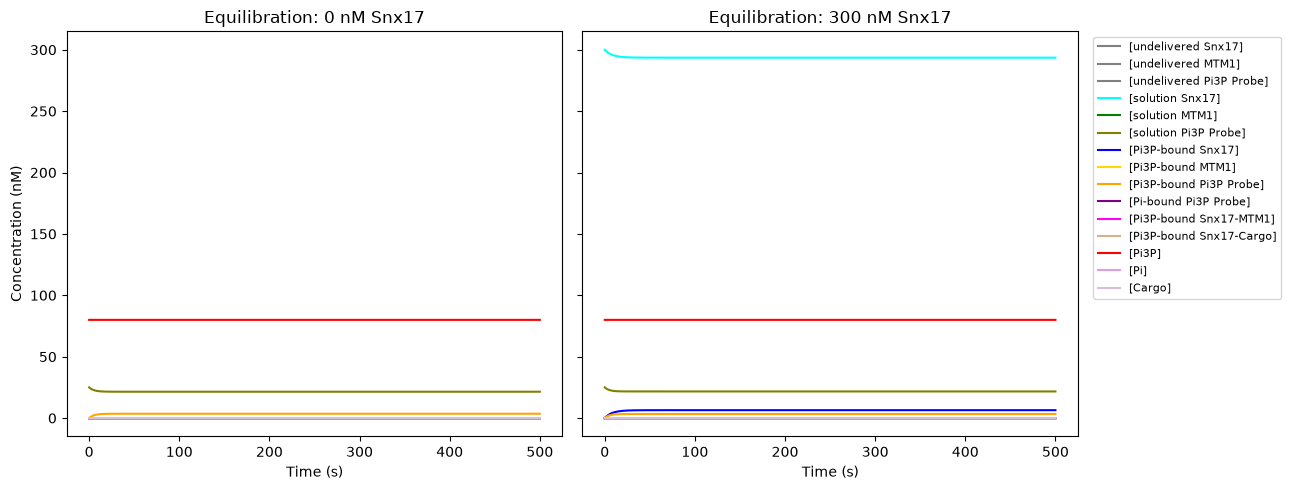

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, dose, result in zip(axes, [0, 300], [sol_eq_0, sol_eq_300]):
    for i, name in enumerate(label_list):
        ax.plot(result.t, result.y[i], label=name, color=colour_list[i])
    ax.set(title=f"Equilibration: {dose} nM Snx17", xlabel="Time (s)")
axes[0].set_ylabel("Concentration (nM)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## 11. Plot assay curves and the areas being compared

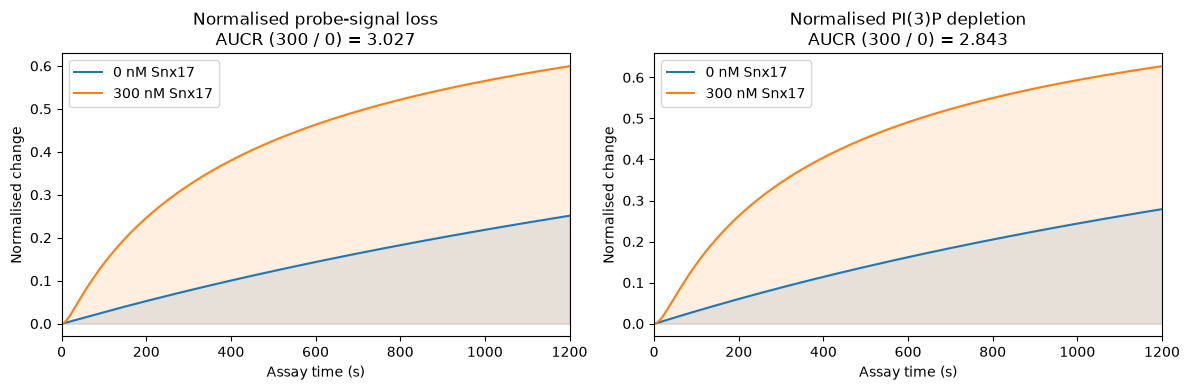

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["Normalised probe-signal loss", "Normalised PI(3)P depletion"]):
    for dose, color in [(0, "tab:blue"), (300, "tab:orange")]:
        t, values = runs[dose].t, curves[dose][metric]
        ax.plot(t, values, color=color, label=f"{dose} nM Snx17")
        ax.fill_between(t, 0, values, color=color, alpha=0.12)
    ratio = auc_summary.loc[auc_summary["Curve"] == metric, "AUCR (300 / 0)"].iloc[0]
    ax.set(title=f"{metric}\nAUCR (300 / 0) = {ratio:.3f}",
           xlabel="Assay time (s)", ylabel="Normalised change", xlim=simulation_time)
    ax.legend()
fig.tight_layout()
plt.show()

## 12. Plot membrane-bound MTM1

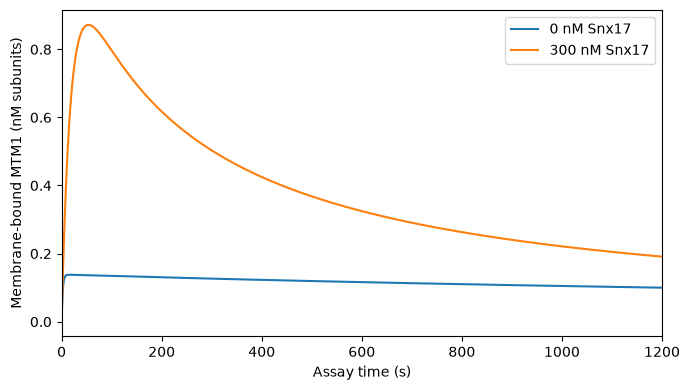

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for dose, result in runs.items():
    bound_mtm1 = result.y[7] + result.y[10]
    ax.plot(result.t, bound_mtm1, label=f"{dose} nM Snx17")
ax.set(xlabel="Assay time (s)", ylabel="Membrane-bound MTM1 (nM subunits)",
       xlim=simulation_time)
ax.legend()
fig.tight_layout()
plt.show()


## 13. Optional experimental overlay (excluded from AUC calculations)

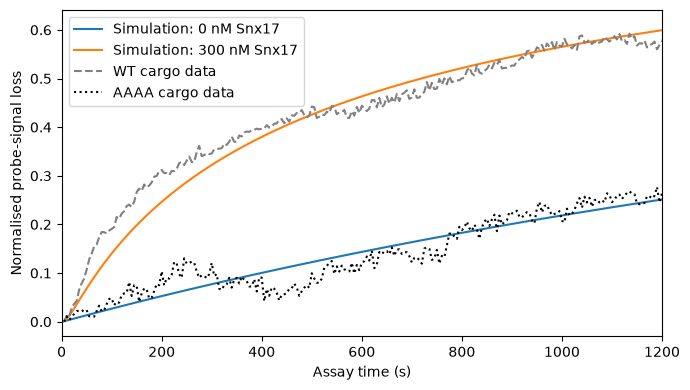

In [13]:
if experimental_csv.is_file():
    df = pd.read_csv(experimental_csv)
    df_time = df[file_settings["time_column"]] * file_settings["time_to_seconds"]
    fig, ax = plt.subplots(figsize=(7, 4))
    for dose, result in runs.items():
        ax.plot(result.t, curves[dose]["Normalised probe-signal loss"],
                label=f"Simulation: {dose} nM Snx17")
    ax.plot(df_time, df[file_settings["A_column"]], "--", color="grey", label="WT cargo data")
    ax.plot(df_time, df[file_settings["B_column"]], ":", color="black", label="AAAA cargo data")
    ax.set(xlabel="Assay time (s)", ylabel="Normalised probe-signal loss", xlim=simulation_time)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print(f"Optional experimental overlay skipped: {experimental_csv.name} not found.")

## 14. Export both trajectories and the AUC comparison

In [14]:
for dose, result in runs.items():
    output = results_csv.with_name(f"{results_csv.stem}_Snx17_{dose}nM.csv")
    table = pd.DataFrame({"time_s": result.t,
                          "Snx17_at_equilibration_nM": dose})
    for i, name in enumerate(label_list):
        table[name + " (nM)"] = result.y[i]
    for metric, values in curves[dose].items():
        table[metric] = values
    table.to_csv(output, index=False)
    print(f"Saved {output.name}")
summary_path = results_csv.with_name(f"{results_csv.stem}_AUC_comparison.csv")
auc_summary.to_csv(summary_path, index=False)
print(f"Saved {summary_path.name}")

Saved results_Snx17_0nM.csv
Saved results_Snx17_300nM.csv
Saved results_AUC_comparison.csv


## 15. Sensitivity-analysis settings and helper functions


In [15]:
from copy import deepcopy

SA_FACTORS = (0.5, 2.0)
SA_OUTPUT_STEP_S = 1.0
SA_SOLVER = {"method": "LSODA", "rtol": 1e-7, "atol": 1e-9}
SA_BASELINE_RTOL = 0.001

sa_config = deepcopy(config)
# Freeze inherited catalytic value before varying coefficients independently.
if sa_config["catalysis"]["keff_SM"] is None:
    sa_config["catalysis"]["keff_SM"] = sa_config["catalysis"]["keff_M"]
sa_targets = [("affinities", name) for name in sa_config["affinities"]]
sa_targets += [("catalysis", name) for name in ("keff_M", "keff_SM")]
sa_targets += [("membrane", "membrane_substrate")]
for section, name in sa_targets:
    if not np.isfinite(sa_config[section][name]) or sa_config[section][name] <= 0:
        raise ValueError(f"{name} must be positive for a fold-change analysis.")
if 2 * sa_config["membrane"]["membrane_substrate"] + sa_config["membrane"]["membrane_product"] > 1:
    raise ValueError("Doubling membrane_substrate would make substrate + product fractions exceed 1.")

def sensitivity_parameters(config):
    affinities = config["affinities"]
    Volume = config["geometry"]["Volume"]
    TotalMembraneSA = config["geometry"]["TotalMembraneSA"]

    keff_M = config["catalysis"]["keff_M"]
    keff_SM = config["catalysis"]["keff_SM"]
    if keff_SM is None:
        keff_SM = keff_M

    params = dict(config["association_rates"])
    ref = config["dissociation_reference"]
    for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                            ("PA", "Kd_PA"), ("PB", "Kd_PB")]:
        reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
        params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])
    for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC")]:
        params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])

    divisors = config["complex_off_rate_divisors"]
    params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
    params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
    params.update(keff_M=keff_M, keff_SM=keff_SM,
                  ka=config["transport"]["ka"])

    return params, Volume, TotalMembraneSA

def sensitivity_pair(settings):
    local_params, volume, area = sensitivity_parameters(settings)
    eq = settings["equilibration"]
    assay = settings["assay"]
    mem = settings["membrane"]
    times = np.linspace(assay["time_s"][0], assay["time_s"][1],
                        int(np.ceil((assay["time_s"][1] - assay["time_s"][0]) / SA_OUTPUT_STEP_S)) + 1)
    aucs = {}
    for dose in (0, 300):
        y0 = np.zeros(15)
        y0[3:6] = [dose, eq["MTM1_conc"], eq["Probe_conc"]]
        y0[12:15] = [mem["PC_concentration"] * mem["membrane_substrate"],
                     mem["PC_concentration"] * mem["membrane_product"],
                     mem["PC_concentration"] * eq["cargo_fraction"]]
        eq_result = solve_ivp(model, eq["time_s"], y0,
                              args=(local_params, volume, area), **SA_SOLVER)
        if not eq_result.success:
            raise RuntimeError(eq_result.message)
        assay_y0 = eq_result.y[:, -1].copy()
        assay_y0[3:6] += [assay["Snx17_conc"], assay["MTM1_conc"], assay["Probe_conc"]]
        result = solve_ivp(model, assay["time_s"], assay_y0, t_eval=times,
                           args=(local_params, volume, area), **SA_SOLVER)
        if not result.success:
            raise RuntimeError(result.message)
        available_curves = {
            "Normalised probe-signal loss": normalised_loss(result.y[8]),
            "Normalised PI(3)P depletion": normalised_loss(result.y[12]),
            "Bound PI(3)P probe": result.y[8],
            "Total PI(3)P": result.y[12],
        }
        aucs[dose] = calculate_auc(result.t, available_curves[primary_metric])
    if not all(np.isfinite(v) and v > 1e-12 for v in aucs.values()):
        raise ValueError("Sensitivity comparison requires finite, positive AUCs.")
    return {"AUC_MTM1_only": aucs[0], "AUC_MTM1_Snx17": aucs[300],
            "AUCR": aucs[300] / aucs[0]}


## 16. Execute sensitivity analysis (no plotting)

In [16]:
sa_baseline = sensitivity_pair(sa_config)
main_row = auc_summary.loc[auc_summary["Curve"] == primary_metric].iloc[0]
for key, main_column in [("AUC_MTM1_only", "AUC (0 nM Snx17)"),
                          ("AUC_MTM1_Snx17", "AUC (300 nM Snx17)"),
                          ("AUCR", "AUCR (300 / 0)")]:
    if not np.isclose(sa_baseline[key], main_row[main_column], rtol=SA_BASELINE_RTOL, atol=1e-8):
        raise RuntimeError("Sensitivity baseline differs from the main runs. Restart and Run All; "
                           "if it persists, refine the solver/output settings before comparing.")
print("Baseline agreement check passed.", flush=True)
sa_records = []
for section, name in sa_targets:
    baseline_value = sa_config[section][name]
    for factor in SA_FACTORS:
        perturbed = deepcopy(sa_config)
        perturbed[section][name] = baseline_value * factor
        result = sensitivity_pair(perturbed)
        record = {"parameter": name, "section": section, "factor": factor,
                  "baseline_parameter": baseline_value,
                  "tested_parameter": baseline_value * factor,
                  "curve": primary_metric, **result}
        for metric, baseline in sa_baseline.items():
            record[metric + "_baseline"] = baseline
            record[metric + "_change_percent"] = 100 * (result[metric] / baseline - 1)
        sa_records.append(record)
    print(f"Completed {name}: 0.5x and 2x", flush=True)
sa_results = pd.DataFrame(sa_records)
print(sa_results[["parameter", "factor", "AUC_MTM1_only", "AUC_MTM1_Snx17", "AUCR"]]
      .to_string(index=False, float_format=lambda x: f"{x:.6g}"))

Baseline agreement check passed.
Completed Kd_SA: 0.5x and 2x
Completed Kd_MA: 0.5x and 2x
Completed Kd_PA: 0.5x and 2x
Completed Kd_PB: 0.5x and 2x
Completed Kd_SM: 0.5x and 2x
Completed Kd_SC: 0.5x and 2x
Completed keff_M: 0.5x and 2x
Completed keff_SM: 0.5x and 2x
Completed membrane_substrate: 0.5x and 2x
         parameter  factor  AUC_MTM1_only  AUC_MTM1_Snx17    AUCR
             Kd_SA     0.5        164.974         581.993 3.52778
             Kd_SA       2        164.974         403.969 2.44868
             Kd_MA     0.5        279.474         616.563 2.20616
             Kd_MA       2        90.9403         374.254 4.11538
             Kd_PA     0.5        140.982          449.64 3.18934
             Kd_PA       2        181.078         529.329  2.9232
             Kd_PB     0.5        165.197         499.732 3.02507
             Kd_PB       2        164.863         499.085 3.02728
             Kd_SM     0.5        164.974         598.817 3.62976
             Kd_SM       2    

## 17. Plot sensitivity: three separate figures

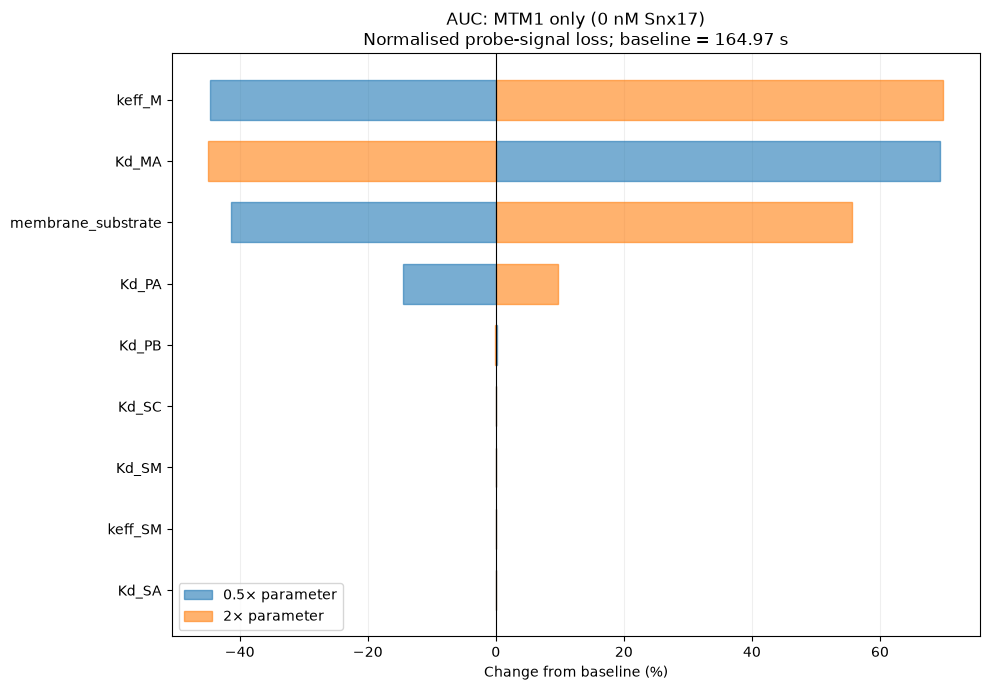

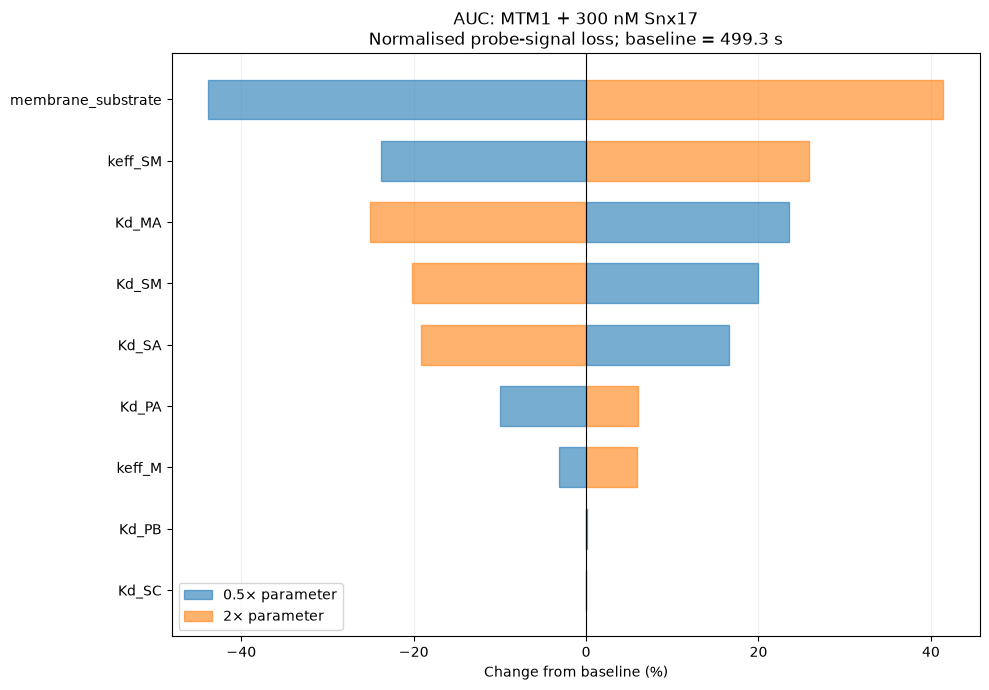

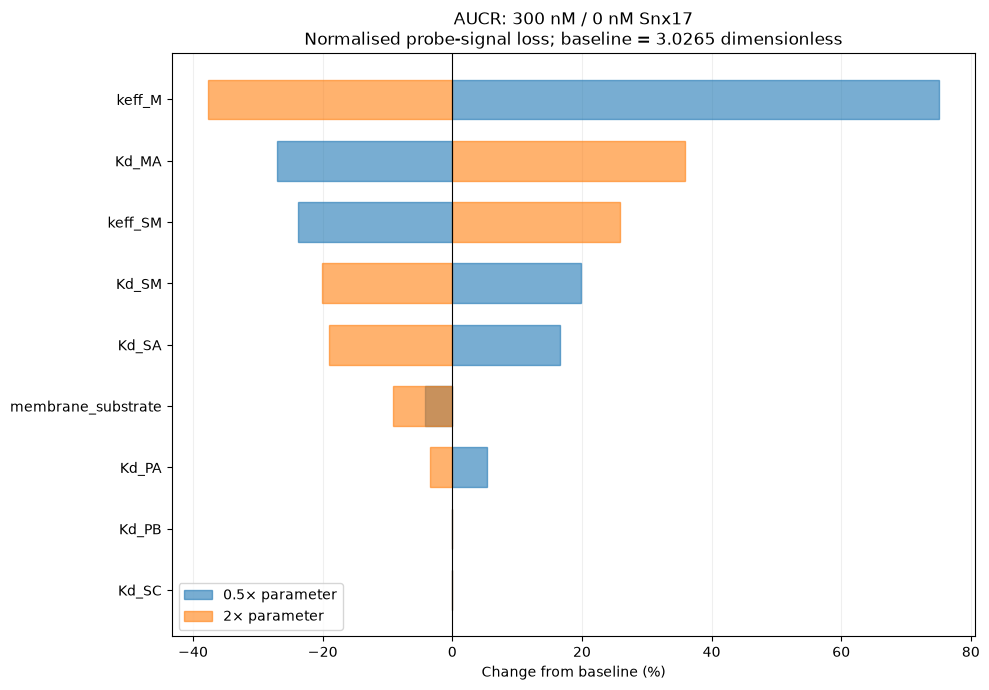

In [17]:
auc_units = main_row["AUC units"]
for metric, title, unit in [
    ("AUC_MTM1_only", "AUC: MTM1 only (0 nM Snx17)", auc_units),
    ("AUC_MTM1_Snx17", "AUC: MTM1 + 300 nM Snx17", auc_units),
    ("AUCR", "AUCR: 300 nM / 0 nM Snx17", "dimensionless"),
]:
    column = metric + "_change_percent"
    ranked = sa_results.groupby("parameter")[column].apply(lambda v: v.abs().max()).sort_values()
    names = ranked.index.tolist()
    y = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(10, 7))
    for factor, color in [(0.5, "tab:blue"), (2.0, "tab:orange")]:
        values = sa_results[sa_results["factor"] == factor].set_index("parameter").loc[names, column]
        ax.barh(y, values, height=0.65, color=color, alpha=0.6,
                edgecolor=color, linewidth=1, label=f"{factor:g}× parameter")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y, labels=names)
    ax.set_xlabel("Change from baseline (%)")
    ax.set_title(f"{title}\n{primary_metric}; baseline = {sa_baseline[metric]:.5g} {unit}")
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend()
    fig.tight_layout()
    plt.show()

## 18. Export sensitivity results

In [18]:
sa_output = results_csv.with_name(f"{results_csv.stem}_sensitivity.csv")
sa_results.to_csv(sa_output, index=False)
print(f"Saved {sa_output.name}")

Saved results_sensitivity.csv
